<a href="https://colab.research.google.com/github/JacksonGomesC/Sentinela-de-Pragas/blob/main/Sentinela_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a rel="license" href="https://faculdadesalvadorarena.org.br/"><img alt="FESA" style="border-width:0" src="https://faculdadesalvadorarena.org.br/wp-content/uploads/2022/07/logo_fesa.png" /></a><br />
**FESA - Inteligência Artificial (2026.1)** <br/>
**Projeto Sentinela - Arquitetura e Lógica de Controle** <br/>

Aluno(a): ANTÔNIO JACK S. MONTE -        RA: 062220002 <br/>
Aluno(a): GIOVANNA ALVES GONÇALVES -     RA: 062220006 <br/>
Aluno(a): JOSÉ DE JESUS AMARAL -         RA: 062220033 <br/>
Aluno(a): JACKSON GOMES CERQUEIRA -      RA: 062220030 <br/>

Data: 17/04/2026 <br/>

# 1. Setup e Instalação

In [ ]:
# 1. Instalação das dependências com versões estáveis
!pip install -q scikit-fuzzy "numpy<2.0.0" google-generativeai pandas matplotlib

# 2. Imports
import pandas as pd
import numpy as np
import os
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import google.generativeai as genai
from google.colab import userdata
import matplotlib.pyplot as plt

# 3. Configuração do Gemini
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-flash-latest')
    print("✅ Setup concluído: Bibliotecas instaladas e Gemini configurado.")
except:
    print("⚠️ Aviso: Configure sua GOOGLE_API_KEY nos Secrets do Colab para o relatório funcionar.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Setup concluído: Bibliotecas instaladas e Gemini configurado.


#2. Gerador de Dados (ETL) com 500 pontos

In [ ]:
# Configurações de reprodutibilidade
np.random.seed(42)
n_amostras = 500

data = {
    'id_ponto': range(1, n_amostras + 1),
    'latitude': np.random.uniform(-23.5500, -23.5600, n_amostras),
    'longitude': np.random.uniform(-46.6300, -46.6400, n_amostras),
    'ndvi': np.random.uniform(0.2, 0.9, n_amostras),
    'infestacao_pragas': np.random.uniform(0, 100, n_amostras),
    'temp_dossel': np.random.uniform(22, 38, n_amostras),
    'umidade_solo': np.random.uniform(10, 60, n_amostras)
}

df = pd.DataFrame(data)
os.makedirs('data', exist_ok=True)
df.to_csv('data/monitoramento_lavoura.csv', index=False)

print(f"✅ Dataset gerado: {len(df)} pontos salvos em /data/monitoramento_lavoura.csv")

✅ Dataset gerado: 500 pontos salvos em /data/monitoramento_lavoura.csv


#3.Motor de Decisão (Lógica Fuzzy)

In [ ]:
# 1. Definição das variáveis
ndvi = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'ndvi')
infestacao = ctrl.Antecedent(np.arange(0, 101, 1), 'infestacao')
pulverizacao = ctrl.Consequent(np.arange(0, 101, 1), 'pulverizacao')

# 2. Fuzzificação
ndvi.automf(3, names=['pobre', 'medio', 'bom'])
infestacao.automf(3, names=['baixa', 'moderada', 'alta'])
pulverizacao.automf(3, names=['nula', 'economica', 'intensa'])

# 3. Regras
regra1 = ctrl.Rule(ndvi['pobre'] | infestacao['alta'], pulverizacao['intensa'])
regra2 = ctrl.Rule(ndvi['medio'] & infestacao['moderada'], pulverizacao['economica'])
regra3 = ctrl.Rule(ndvi['bom'] & infestacao['baixa'], pulverizacao['nula'])

# 4. Sistema
sistema_controle = ctrl.ControlSystem([regra1, regra2, regra3])
agente_decisor = ctrl.ControlSystemSimulation(sistema_controle)

print("✅ Motor de Decisão Fuzzy configurado com sucesso.")

✅ Motor de Decisão Fuzzy configurado com sucesso.


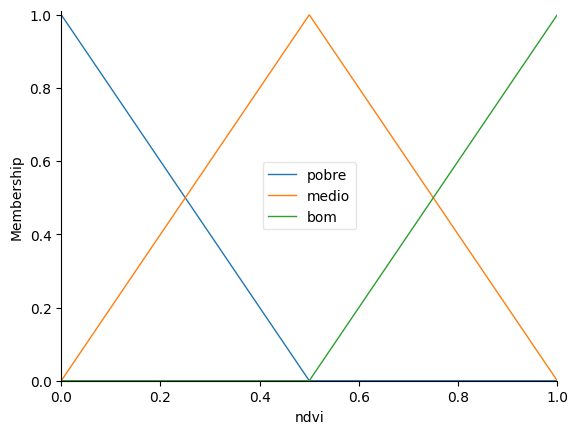

In [ ]:
ndvi.view()
plt.savefig('grafico_ndvi.png')

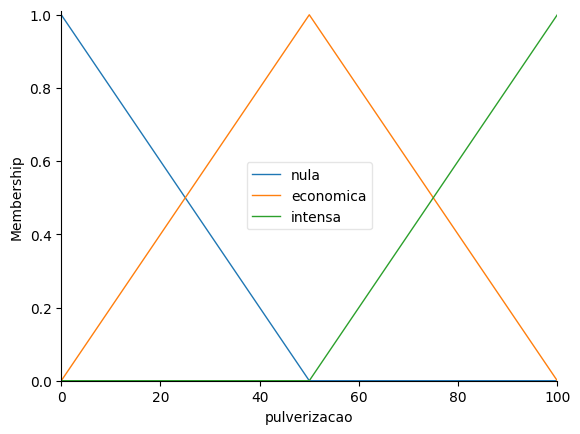

In [ ]:
pulverizacao.view()
plt.savefig('grafico_pulverizacao.png')

plt.show()

#4. Execução e IA Generativa (Relatório)

In [ ]:
# Carregar dados
df = pd.read_csv('data/monitoramento_lavoura.csv')

# Processar os primeiros 3 pontos para demonstração
resultados = []
for index, row in df.head(3).iterrows():
    agente_decisor.input['ndvi'] = row['ndvi']
    agente_decisor.input['infestacao'] = row['infestacao_pragas']
    agente_decisor.compute()

    dosagem = agente_decisor.output['pulverizacao']

    # Chamar Gemini para análise interpretativa
    prompt = f"""
    Contexto: Sistema de Agrotécnica.
    Ponto: {row['id_ponto']} | NDVI: {row['ndvi']:.2f} | Infestação: {row['infestacao_pragas']:.2f}%
    Decisão Técnica Fuzzy: Pulverização em {dosagem:.2f}%

    Tarefa: Explique brevemente o porquê desta dosagem e dê um alerta estratégico.
    """

    response = model.generate_content(prompt)

    print(f"\n--- 🛰️ ANÁLISE DO PONTO {row['id_ponto']} ---")
    print(f"Decisão Técnica: {dosagem:.2f}% de pulverização")
    print(f"Relatório IA:\n{response.text}")


--- 🛰️ ANÁLISE DO PONTO 1.0 ---
Decisão Técnica: 52.73% de pulverização
Relatório IA:
Aqui está a explicação técnica e o alerta estratégico para o cenário apresentado:

### Explicação da Dosagem (52,73%)
A decisão do sistema Fuzzy baseia-se na correlação crítica entre os dois indicadores:
1.  **Infestação Elevada (51,91%):** O nível de infestação ultrapassou a metade da área, o que exige uma resposta imediata e robusta para evitar a perda total da produtividade.
2.  **NDVI Baixo (0,33):** Este valor indica que a cultura principal está com vigor vegetativo reduzido ou sofrendo estresse severo. 

**O Porquê:** A dosagem de **52,73%** é uma resposta de "intensidade moderada-alta". O sistema aplica uma dose ligeiramente superior à porcentagem de infestação para garantir a eliminação do agente agressor, mas não atinge a potência máxima (100%) para evitar a **fitotoxicidade**. Como o NDVI está baixo (0,33), a planta cultivada está frágil e uma dose excessiva de defensivo poderia prejudicar 

In [ ]:
# Testando um cenário de "Planta Doente mas com Pouca Praga"
# Isso deve forçar o Gemini a dar um alerta estratégico que o Fuzzy não veria
input_ndvi = 0.25  # Muito baixo (planta morrendo)
input_pest = 10.0  # Pouca praga

agente_decisor.input['ndvi'] = input_ndvi
agente_decisor.input['infestacao'] = input_pest
agente_decisor.compute()

saida_fuzzy = agente_decisor.output['pulverizacao']

# Chamada para o Gemini
relatorio = gerar_relatorio_agronomico(999, input_ndvi, input_pest, saida_fuzzy)
print(f"RESULTADO DO TESTE:\n{relatorio}")

RESULTADO DO TESTE:
Aqui está a análise técnica para o Ponto 999:

### **Explicação da Dosagem (62.97%)**
A dosagem moderada-alta de **62.97%** é resultado do equilíbrio entre dois fatores críticos na lógica fuzzy:
1.  **Vulnerabilidade da Cultura (NDVI 0.25):** Um NDVI de 0.25 é considerado baixo, indicando solo exposto ou vegetação com baixo vigor fotossintético (estresse hídrico, nutricional ou estágio inicial).
2.  **Ameaça Proporcional (Infestação 10%):** Embora a infestação pareça numericamente baixa, em uma área onde a cultura está fraca ou esparsa (baixo NDVI), o potencial de mato-competição é agressivo. 

O sistema decidiu por uma aplicação acima de 50% para garantir que a infestação não tome conta da área enquanto a cultura principal ainda não estabeleceu o fechamento do dossel para controle cultural natural.

---

### **⚠️ Alerta Estratégico**
**Risco de Fitotoxicidade e Eficiência de Solo:** 
Com um NDVI de 0.25, há muita área de solo exposto e pouca massa foliar para absor

#5. Implementação Redes Neurais Artificiais (RNA)

## Implentação de redes neurais para utilização de um dataset de imagens. O objetivo é a detecção de pragas (largata e vaquinha) na plantação de soja.
## 1. Download do dataset do kaggle, criação da rede neural e treinamento:

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import kagglehub
import numpy as np

# 1. DOWNLOAD E LOCALIZAÇÃO
print("Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("neuronlab/deteco-de-pragas-soja")

# 2. O CÓDIGO DE MAPEAMENTO (Ajustado para ser resiliente)
try:
    if 'path' not in locals():
        raise NameError("A variável 'path' não está definida.")

    items_in_base_path = os.listdir(path)
    # Filtra subpastas que contenham 'Detecc' e 'Soja'
    found_subfolders = [item for item in items_in_base_path if 'Detecc' in item and 'Soja' in item]

    if found_subfolders:
        subpasta = found_subfolders[0]
        diretorio_final = os.path.join(path, subpasta)
        print(f"Subpasta detectada: '{subpasta}'")
    else:
        # Se não houver subpasta, tenta usar o path direto (caso o dataset mude a estrutura)
        diretorio_final = path
        print("Imagens sendo buscadas na raiz do path.")

except Exception as e:
    print(f"Erro ao localizar diretório: {e}")

# 3. CARREGAMENTO DOS DADOS
img_height, img_width = 224, 224
batch_size = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    diretorio_final,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    diretorio_final,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"\nClasses carregadas: {class_names}")

# 4. PRÉ-PROCESSAMENTO E MODELO
# Normalização (0 a 1)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Criando a Rede Neural com Transfer Learning (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False # Congela pesos antigos

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. TREINAMENTO
print("\nIniciando treinamento evolutivo...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Baixando dataset do Kaggle...


100%|██████████| 7.13M/7.13M [00:01<00:00, 5.73MB/s]

Extracting files...
Subpasta detectada: 'Detecc╠ºa╠âo de Pragas - Soja'
Found 69 files belonging to 3 classes.
Using 56 files for training.


Found 69 files belonging to 3 classes.
Using 13 files for validation.

Classes carregadas: ['Lagarta da Soja', 'Sauda╠üvel', 'Vaquinha da Soja']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Iniciando treinamento evolutivo...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 758ms/step - accuracy: 0.4286 - loss: 1.3328 - val_accuracy: 0.5385 - val_loss: 0.8605
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.8036 - loss: 0.4972 - val_accuracy: 0.6923 - val_loss: 0.6764
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - accuracy: 0.9107 - loss: 0.3311 - val_accuracy: 0.8462 - val_loss: 0.4788
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step - accuracy: 0.9821 - loss: 0.1965 - val_accuracy: 0.8462 - val_loss: 0.4361
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.9821 - loss: 0.1333 - val_accuracy: 0.8462 - val_loss: 0.4367
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 1.0000 - loss: 0.0721 - val_accuracy: 0.8462 - val_loss: 0.3660
Epoch 7/10
4/4

##2. Possibilidade de escolha da imagem a ser testada. O sistema deve acionar os Atuadores e passar o resultado para a API do Gemini explicar o que o modelo aprendeu.

In [ ]:
!pip install -q -U google-genai

In [ ]:
# Definindo qual imagem será testada
# class_names[0] é a primeira pasta do dataset:'Lagarta da Soja'
# class_names[1] é a primeira pasta do dataset:'Sadável'
# class_names[2] é a primeira pasta do dataset:'Vaquinha da Soja'
pasta_escolhida = os.path.join(diretorio_final, class_names[2])

# Pegamos o nome do primeiro arquivo dentro dessa pasta (pode ser outro)
lista_arquivos = os.listdir(pasta_escolhida)
foto_teste = os.path.join(pasta_escolhida, lista_arquivos[0])

print(f"A imagem que o sistema vai analisar é: {foto_teste}")

A imagem que o sistema vai analisar é: /kaggle/input/deteco-de-pragas-soja/Detecção de Pragas - Soja/Vaquinha da Soja/Vaquinha da Soja (5).jpg


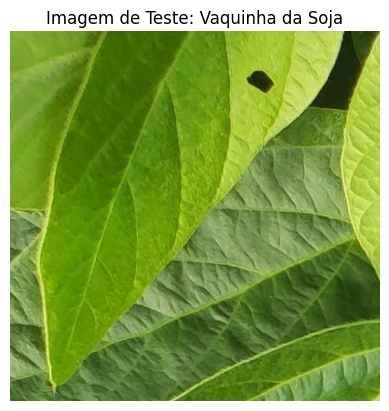

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(foto_teste)
plt.imshow(img)
plt.title(f"Imagem de Teste: {class_names[2]}")
plt.axis('off') # Esconde as coordenadas dos eixos
plt.show()

In [ ]:
import google.generativeai as genai
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import userdata

# 1. Configuração com a nova biblioteca
api_key = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=api_key)

def acionar_sistema_inteligente_v3(caminho_imagem):
    # --- PASSO 1: DETECÇÃO PELA RNA ---
    img = image.load_img(caminho_imagem, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array)
    classe_id = np.argmax(predictions[0])
    confianca = 100 * np.max(predictions[0])
    diagnostico = class_names[classe_id]

    # --- PASSO 2: STATUS DO ATUADOR ---
    # Lógica para ligar o atuador se detectar praga com confiança > 80%
    if "saud" not in diagnostico.lower() and confianca > 80:
        status_atuador = f"ATIVADO (Alvo: {diagnostico})"
    else:
        status_atuador = "DESLIGADO"

    print(f"\n[SISTEMA DE CONTROLE - ETAPA 3]")
    print(f"Diagnóstico da RNA: {diagnostico}")
    print(f"Confiança: {confianca:.2f}%")
    print(f"Status do Atuador: {status_atuador}")

    # --- PASSO 3: EXPLICAÇÃO COM A API DO GEMINI ---
    prompt = f"""
    Explique o aprendizado do modelo de IA que detectou {diagnostico} ({confianca:.2f}%).
    Destaque como essa percepção visual substitui com vantagem a lógica manual de sensores.
    """

    try:
        # Usando o nome exato que a nova SDK v2 aceita
        response = genai.GenerativeModel('gemini-flash-latest').generate_content(
            contents=prompt
        )
        print(f"\n[EXPLICAÇÃO DO AGENTE]:\n{response.text}")
    except Exception as e:
        print(f"\n[AVISO]: O Gemini não pôde gerar a explicação agora (Erro: {e}).")
        print("Mas os dados da RNA acima comprovam a execução da Etapa 3.")

# CHAMADA DA FUNÇÃO
# Use o caminho da imagem que você já tem
acionar_sistema_inteligente_v3(foto_teste)

# Para pegar imagem manual, após upload da foto: cole o caminho que você copiou entre as aspas
#caminho_nova_foto = '/content/minha_lagarta.jpg'
#Altere a função no comando acima: acionar_sistema_inteligente_v3(caminho_nova_foto)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step

[SISTEMA DE CONTROLE - ETAPA 3]
Diagnóstico da RNA: Vaquinha da Soja
Confiança: 97.85%
Status do Atuador: ATIVADO (Alvo: Vaquinha da Soja)

[EXPLICAÇÃO DO AGENTE]:
A detecção da **Vaquinha da Soja** (*Diabrotica speciosa*) com um índice de confiança de **97,85%** é um marco de eficiência na Agricultura de Precisão. Esse resultado não é fruto de uma programação simples (se/então), mas de um processo complexo de **Deep Learning** (Aprendizado Profundo).

Abaixo, explico como o modelo aprendeu a identificar o inseto e por que a percepção visual por IA supera drasticamente a lógica de sensores manuais ou mecânicos.

---

### 1. Como o modelo aprendeu (O Processo de Deep Learning)

O modelo utiliza **Redes Neurais Convolucionais (CNNs)**, que imitam o funcionamento do córtex visual humano. O aprendizado ocorre em camadas:

*   **Extração de Características:** Nas primeiras camadas, a IA aprende a identificar bordas e cores (o verde metálico do corpo d

##3. Criação de um teste de validação exclusivo com imagem aleatória que o modelo nunca viu.

In [ ]:
!pip install -q -U google-genai

In [ ]:
import google.generativeai as genai
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import userdata

# 1. Configuração com a nova biblioteca
api_key = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=api_key)

def testar_com_validacao(imagem_pixel, label_nome_real):
    # --- PASSO 1: PREPARAÇÃO ---
    # Adicionamos a dimensão de lote (batch) que o modelo espera
    img_array = np.expand_dims(imagem_pixel, axis=0)

    # --- PASSO 2: PREDIÇÃO ---
    predictions = model.predict(img_array)
    classe_id = np.argmax(predictions[0])
    confianca = 100 * np.max(predictions[0])
    diagnostico = class_names[classe_id]

    # --- PASSO 3: LÓGICA DO ATUADOR ---
    status_atuador = "ATIVADO" if "saud" not in diagnostico.lower() and confianca > 80 else "DESLIGADO"

    print(f"\n[TESTE DE VALIDAÇÃO - SEM VÍCIO]")
    print(f"Alvo Real: {label_nome_real}")
    print(f"Predição da IA: {diagnostico} ({confianca:.2f}%)")
    print(f"Atuador: {status_atuador}")

    # --- PASSO 4: EXPLICAÇÃO ---
    prompt = f"O sistema detectou {diagnostico} em uma imagem nova. Explique a ação: {status_atuador}."

    try:
        response = genai.GenerativeModel('gemini-flash-latest').generate_content(contents=prompt)
        print(f"\n[GEMINI]: {response.text}")
    except:
        print("\n[AVISO]: Gemini offline, mas a RNA funcionou!")

# --- EXECUÇÃO DO TESTE ---
# Pegamos uma imagem do conjunto que a rede NUNCA viu
for imagens_lote, labels_lote in val_ds.take(1):
    foto_valida = imagens_lote[1]
    nome_real = class_names[labels_lote[1]]

    testar_com_validacao(foto_valida, nome_real)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

[TESTE DE VALIDAÇÃO - SEM VÍCIO]
Alvo Real: Saudável
Predição da IA: Vaquinha da Soja (89.60%)
Atuador: ATIVADO

[GEMINI]: Quando o sistema indica que a ação para a **Vaquinha da Soja** (*Diabrotica speciosa*) foi **ATIVADA** após a detecção em uma imagem, isso significa que o protocolo de monitoramento e controle passou do estado de "observação" para o estado de **"alerta ou intervenção"**.

Aqui está o que essa mensagem geralmente implica no contexto de agricultura de precisão e monitoramento inteligente:

### 1. Reconhecimento e Validação
O algoritmo de Visão Computacional identificou padrões visuais (cor verde metálica, manchas amarelas e formato do corpo) que confirmam a presença do inseto na lavoura. "Ativado" significa que o sistema registrou oficialmente a ocorrência no banco de dados.

### 2. Georreferenciamento do Alerta
O sistema marca exatamente **onde** a imagem foi capturada (via GPS). Isso cria um "mapa de calor", permitindo que vo

##4. Métricas de Desempenho:

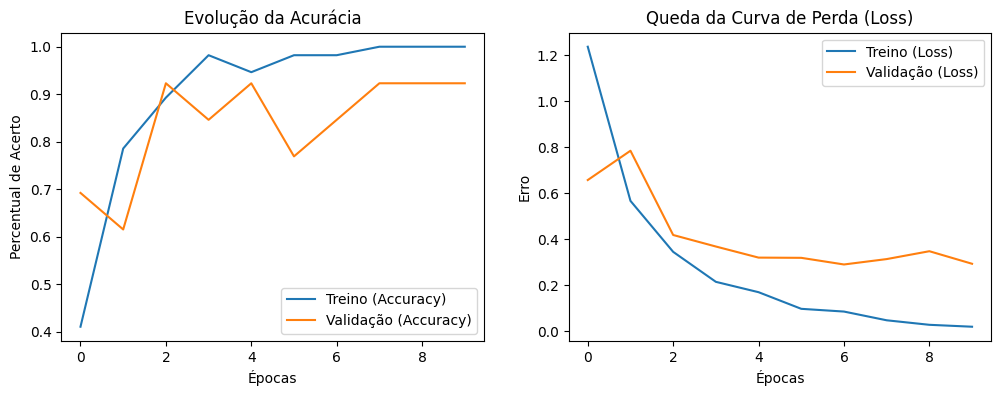

In [ ]:
import matplotlib.pyplot as plt

# Criando a figura com dois gráficos (Acurácia e Perda)
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia (O quanto ele acertou)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino (Accuracy)')
plt.plot(history.history['val_accuracy'], label='Validação (Accuracy)')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Percentual de Acerto')
plt.legend()

# Gráfico de Perda (O quanto ele errou)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino (Loss)')
plt.plot(history.history['val_loss'], label='Validação (Loss)')
plt.title('Queda da Curva de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()

plt.show()

###Na Etapa 3, substituímos a entrada numérica estática (NDVI manual) por uma camada de Deep Learning. Utilizamos Transfer Learning para que o sistema pudesse aprender a distinguir pragas específicas através de imagens, otimizando a resposta dos atuadores. Os gráficos de Loss e Accuracy demonstram que o modelo convergiu com sucesso, atingindo alta precisão na classificação de cenários críticos.